In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data_1 = pd.read_csv("/content/drive/MyDrive/Grad project/dataset_v2_master_training.csv", low_memory=False)
data_1.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,flow_duration,total_packets,total_bytes,avg_packet_size,...,arp_reply_rate,arp_request_rate,arp_reply_request_ratio,arp_gratuitous_count,arp_unsolicited_count,mac_ip_binding_changes,ip_mac_binding_changes,label,attack_type,snort_sid
0,2026-06-20T21:29:32.987864,10.0.0.3,10.0.0.4,0,0,ARP,0.0049,4,168,42.0,...,0.0000,4041.7287,0.0000,0,0,0,0,0,normal,none
1,2026-06-20T21:29:32.989954,10.0.0.4,10.0.0.3,0,0,ARP,0.0025,2,84,42.0,...,810.8069,6486.4551,0.1176,0,0,0,0,0,normal,none
2,2026-06-20T21:29:32.992616,10.0.0.3,10.0.0.4,0,0,ICMP,0.0961,3,294,98.0,...,0.0000,0.0000,0.0000,0,0,0,0,0,normal,none
3,2026-06-20T21:29:32.995119,10.0.0.4,10.0.0.3,0,0,ICMP,0.0934,2,196,98.0,...,0.0000,0.0000,0.0000,0,0,0,0,0,normal,none
4,2026-06-20T21:29:33.015020,10.0.0.3,10.0.0.5,0,0,ARP,0.0069,4,168,42.0,...,0.0000,2901.2271,0.0000,0,0,0,0,0,normal,none


#Data preprocessing

In [ ]:
data_1_noAttacks = data_1[~data_1['label'].isin([1, 2])]
data_1_noAttacks["label"].value_counts()

,count
label,
0,17189


In [ ]:
feature_dict = data_1_noAttacks.columns.tolist()
print(len(feature_dict))
feature_dict

94


['timestamp',
 'src_ip',
 'dst_ip',
 'src_port',
 'dst_port',
 'protocol',
 'flow_duration',
 'total_packets',
 'total_bytes',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'packets_per_second',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'rst_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_std',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'incomplete_ratio',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential

In [ ]:
features_to_drop = [
  'timestamp',
  'src_ip',
  'dst_ip',
  'src_port',
  'dst_port',
  'top_dst_port',
  'snort_sid',
  'active_snort_alerts',
  'distinct_alert_types',
]
data_1_noAttacks = data_1_noAttacks.drop(columns=features_to_drop, axis=1, errors='ignore')
feature_dict = data_1_noAttacks.columns.tolist()
print(len(feature_dict))
feature_dict

85


['protocol',
 'flow_duration',
 'total_packets',
 'total_bytes',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'packets_per_second',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'rst_count',
 'psh_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_std',
 'inter_arrival_cv',
 'inter_arrival_min',
 'inter_arrival_max',
 'burst_count',
 'burst_duration_avg',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'incomplete_ratio',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'dst_port_std',
 'well_known_port_ratio',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'is_broadcast_dst',
 'flows_per_window',
 'device_total_flows',


In [ ]:
#Dropping unneeded features
features_to_drop = [
  "incomplete_ratio",
  "packets_per_second",
  "total_bytes",
  "device_pkt_rate_deviation",
  "is_broadcast_dst",
  "arp_reply_request_ratio",
  "device_byte_rate_deviation",
  "arp_gratuitous_count",
  "inter_arrival_std",
  "is_registered_iot",
  "ip_mac_binding_changes",
  "rst_count",
  "arp_unsolicited_count",
  "well_known_port_ratio",
  "device_pkt_rate_deviation",
  "burst_duration_avg",
  "broadcast_ratio",
  "arp_reply_rate",
  "burst_count",
  "psh_count",
  "device_unique_dst_ips",
 "mac_ip_binding_changes",
  "device_avg_byte_rate",
  "device_age_seconds",
  "network_avg_flow_duration",
  "inter_arrival_max",
  "dst_port_std",
  "inter_arrival_min",

]
data_1_noAttacks = data_1_noAttacks.drop(columns=features_to_drop, axis=1, errors='ignore')
feature_dict = data_1_noAttacks.columns.tolist()
print(len(feature_dict))
feature_dict

58


['protocol',
 'flow_duration',
 'total_packets',
 'avg_packet_size',
 'min_packet_size',
 'max_packet_size',
 'bytes_per_second',
 'syn_count',
 'ack_count',
 'fin_count',
 'unique_src_ports',
 'unique_dst_ports',
 'inter_arrival_mean',
 'inter_arrival_cv',
 'fwd_packet_count',
 'bwd_packet_count',
 'fwd_bwd_packet_ratio',
 'fwd_bwd_bytes_ratio',
 'fwd_avg_packet_size',
 'bwd_avg_packet_size',
 'reply_rate',
 'syn_ack_ratio',
 'completed_sessions',
 'avg_session_duration',
 'payload_size_entropy',
 'src_port_entropy',
 'icmp_type_entropy',
 'pkt_size_std',
 'pkt_size_variance',
 'small_pkt_ratio',
 'large_pkt_ratio',
 'top_dst_port_ratio',
 'ephemeral_port_ratio',
 'sequential_port_score',
 'flows_per_window',
 'device_total_flows',
 'device_avg_pkt_rate',
 'device_unique_dst_ports',
 'device_new_dst_ratio',
 'device_protocol_dist_tcp',
 'device_protocol_dist_udp',
 'device_protocol_dist_icmp',
 'device_avg_payload_size',
 'device_payload_size_deviation',
 'is_gateway',
 'is_baseline_m

##One Hot Encoder

In [ ]:
data_1_noAttacks_encoded = pd.get_dummies(data_1_noAttacks, prefix='protocol')
data_1_noAttacks_encoded.head()

,flow_duration,total_packets,avg_packet_size,min_packet_size,max_packet_size,bytes_per_second,syn_count,ack_count,fin_count,unique_src_ports,...,network_entropy_dst_port,multicast_ratio,arp_broadcast_ratio,arp_request_rate,label,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP,protocol_normal
0,0.0049,4,42.0,42,42,33950.5214,0,0,0,0,...,0.0,0.0,0.5769,4041.7287,0,True,False,False,False,True
1,0.0025,2,42.0,42,42,34053.8890,0,0,0,0,...,0.0,0.0,0.5769,6486.4551,0,True,False,False,False,True
2,0.0961,3,98.0,98,98,3060.5024,0,0,0,0,...,0.0,0.0,0.5769,0.0000,0,False,True,False,False,True
3,0.0934,2,98.0,98,98,2097.8852,0,0,0,0,...,0.0,0.0,0.5769,0.0000,0,False,True,False,False,True
4,0.0069,4,42.0,42,42,24370.3075,0,0,0,0,...,0.0,0.0,0.5769,2901.2271,0,True,False,False,False,True


##Splitting Data

In [ ]:
x = data_1_noAttacks_encoded.drop('label', axis=1)
x = x.drop('attack_type', axis=1 , errors = "ignore")
y = data_1_noAttacks_encoded['label']
print(len(x.columns.tolist()))
print(x.columns.tolist())
print(y.value_counts())
x

60
['flow_duration', 'total_packets', 'avg_packet_size', 'min_packet_size', 'max_packet_size', 'bytes_per_second', 'syn_count', 'ack_count', 'fin_count', 'unique_src_ports', 'unique_dst_ports', 'inter_arrival_mean', 'inter_arrival_cv', 'fwd_packet_count', 'bwd_packet_count', 'fwd_bwd_packet_ratio', 'fwd_bwd_bytes_ratio', 'fwd_avg_packet_size', 'bwd_avg_packet_size', 'reply_rate', 'syn_ack_ratio', 'completed_sessions', 'avg_session_duration', 'payload_size_entropy', 'src_port_entropy', 'icmp_type_entropy', 'pkt_size_std', 'pkt_size_variance', 'small_pkt_ratio', 'large_pkt_ratio', 'top_dst_port_ratio', 'ephemeral_port_ratio', 'sequential_port_score', 'flows_per_window', 'device_total_flows', 'device_avg_pkt_rate', 'device_unique_dst_ports', 'device_new_dst_ratio', 'device_protocol_dist_tcp', 'device_protocol_dist_udp', 'device_protocol_dist_icmp', 'device_avg_payload_size', 'device_payload_size_deviation', 'is_gateway', 'is_baseline_mature', 'network_active_flows', 'network_total_pps', '

,flow_duration,total_packets,avg_packet_size,min_packet_size,max_packet_size,bytes_per_second,syn_count,ack_count,fin_count,unique_src_ports,...,network_entropy_src_ip,network_entropy_dst_port,multicast_ratio,arp_broadcast_ratio,arp_request_rate,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP,protocol_normal
0,0.0049,4,42.0,42,42,33950.5214,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,4041.7287,True,False,False,False,True
1,0.0025,2,42.0,42,42,34053.8890,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,6486.4551,True,False,False,False,True
2,0.0961,3,98.0,98,98,3060.5024,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,0.0000,False,True,False,False,True
3,0.0934,2,98.0,98,98,2097.8852,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,0.0000,False,True,False,False,True
4,0.0069,4,42.0,42,42,24370.3075,0,0,0,0,...,2.5792,0.0000,0.0,0.5769,2901.2271,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19527,0.0010,1,66.0,66,66,66000.0000,0,1,1,1,...,0.7567,1.3675,0.0,0.0000,0.0000,False,False,True,False,True
19528,0.0010,1,66.0,66,66,66000.0000,0,1,1,1,...,0.7567,1.3675,0.0,0.0000,0.0000,False,False,True,False,True
19529,0.0010,1,66.0,66,66,66000.0000,0,1,1,1,...,0.7567,1.3675,0.0,0.0000,0.0000,False,False,True,False,True
19530,0.0010,1,66.0,66,66,66000.0000,0,1,1,1,...,0.7567,1.3675,0.0,0.0000,0.0000,False,False,True,False,True


##Standarized Data


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled

,flow_duration,total_packets,avg_packet_size,min_packet_size,max_packet_size,bytes_per_second,syn_count,ack_count,fin_count,unique_src_ports,...,network_entropy_src_ip,network_entropy_dst_port,multicast_ratio,arp_broadcast_ratio,arp_request_rate,protocol_ARP,protocol_ICMP,protocol_TCP,protocol_UDP,protocol_normal
0,-0.424683,-0.171063,-0.340777,-0.321602,-0.441289,-0.235075,-0.058944,-0.162112,-0.445054,-0.047510,...,2.100206,-0.985065,0.0,5.653874,6.107134,3.537423,-0.474419,-1.424394,-0.279438,0.0
1,-0.426798,-0.171922,-0.340777,-0.321602,-0.441289,-0.234954,-0.058944,-0.162112,-0.445054,-0.047510,...,2.100206,-0.985065,0.0,5.653874,9.910373,3.537423,-0.474419,-1.424394,-0.279438,0.0
2,-0.344312,-0.171492,-0.140018,0.213208,-0.268414,-0.271203,-0.058944,-0.162112,-0.445054,-0.047510,...,2.100206,-0.985065,0.0,5.653874,-0.180547,-0.282692,2.107843,-1.424394,-0.279438,0.0
3,-0.346692,-0.171922,-0.140018,0.213208,-0.268414,-0.272329,-0.058944,-0.162112,-0.445054,-0.047510,...,2.100206,-0.985065,0.0,5.653874,-0.180547,-0.282692,2.107843,-1.424394,-0.279438,0.0
4,-0.422920,-0.171063,-0.340777,-0.321602,-0.441289,-0.246280,-0.058944,-0.162112,-0.445054,-0.047510,...,2.100206,-0.985065,0.0,5.653874,4.332866,3.537423,-0.474419,-1.424394,-0.279438,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17184,-0.428120,-0.172351,-0.254737,-0.092398,-0.367200,-0.197591,-0.058944,-0.161440,1.094189,-0.046551,...,-0.649700,-0.588787,0.0,-0.171426,-0.180547,-0.282692,-0.474419,0.702053,-0.279438,0.0
17185,-0.428120,-0.172351,-0.254737,-0.092398,-0.367200,-0.197591,-0.058944,-0.161440,1.094189,-0.046551,...,-0.649700,-0.588787,0.0,-0.171426,-0.180547,-0.282692,-0.474419,0.702053,-0.279438,0.0
17186,-0.428120,-0.172351,-0.254737,-0.092398,-0.367200,-0.197591,-0.058944,-0.161440,1.094189,-0.046551,...,-0.649700,-0.588787,0.0,-0.171426,-0.180547,-0.282692,-0.474419,0.702053,-0.279438,0.0
17187,-0.428120,-0.172351,-0.254737,-0.092398,-0.367200,-0.197591,-0.058944,-0.161440,1.094189,-0.046551,...,-0.649700,-0.588787,0.0,-0.171426,-0.180547,-0.282692,-0.474419,0.702053,-0.279438,0.0


## Splitting the data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (13751, 60)
X_val shape: (3438, 60)
y_train shape: (13751,)
y_val shape: (3438,)


#Model training

The first step in model training involves defining and compiling the Autoencoder model using TensorFlow and Keras. An Autoencoder is a type of artificial neural network used for learning efficient data codings in an unsupervised manner. The aim of an autoencoder is to learn a representation (encoding) for a set of data, typically for dimensionality reduction, by training the network to ignore signal 'noise'.

### Autoencoder Architecture:

*   **Input Layer**: Takes the `input_dim` (number of features in your dataset, which is 60 in this case) as input.
*   **Encoder**: This part of the network compresses the input data into a lower-dimensional representation called the `latent_dim` (32 in this case). It consists of two `Dense` layers with 'relu' activation functions.
*   **Decoder**: This part of the network reconstructs the original input from the latent space representation. It also consists of two `Dense` layers, with the final output layer using a 'linear' activation function, which is suitable for reconstructing scaled numerical data.

### Compilation:

*   The `autoencoder` model is compiled using the `adam` optimizer and `mse` (Mean Squared Error) as the loss function. MSE is a common choice for autoencoders as it measures the average of the squares of the errors between the original and reconstructed inputs.

The model is then trained using the training data (`X_train`) as both input and target, as autoencoders learn to reconstruct their own input. The training runs for 50 epochs with a batch size of 128, and validation is performed on `X_val`.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Define the input dimension
input_dim = X_train.shape[1]
latent_dim = 32 # Dimension of the latent space

# Encoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation='relu')(input_layer)
encoder = Dense(latent_dim, activation='relu')(encoder)

# Decoder
decoder = Dense(64, activation='relu')(encoder)
decoder = Dense(input_dim, activation='linear')(decoder) # Linear activation for scaled data

# Autoencoder Model
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Display the model summary
autoencoder.summary()

# Train the autoencoder
history = autoencoder.fit(X_train, X_train, # Input and target are the same for autoencoders
                          epochs=50,
                          batch_size=128,
                          shuffle=True,
                          validation_data=(X_val, X_val),
                          verbose=0) # Set verbose to 1 or 2 for progress output

print("Autoencoder training complete.")
# Can access training loss via history.history['loss']
# And validation loss via history.history['val_loss']

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 60)             │         3,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,996 (46.86 KB)

 Trainable params: 11,996 (46.86 KB)

 Non-trainable params: 0 (0.00 B)

Autoencoder training complete.


This cell explicitly recompiles the autoencoder, which might be redundant if it was already compiled in the previous cell. However, it confirms the optimizer and loss function being used: `adam` and `mse` respectively.

In [ ]:
## Compiling the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')
print("Autoencoder compiled.")

Autoencoder compiled.


This cell is crucial for evaluating the performance of the autoencoder. After training, the model is used to `predict` (reconstruct) the `X_val` dataset. The core idea of anomaly detection with autoencoders is that `normal` data points will have low reconstruction errors because the model was trained on them, while `anomalous` data points will have high reconstruction errors because the model has not 'seen' them before and struggles to reconstruct them.

### Steps:

1.  **Reconstruction**: The autoencoder generates `X_val_reconstructed_deeper` by processing `X_val`.
2.  **Error Calculation**: The `reconstruction_errors_deeper` are calculated by finding the Mean Squared Error (MSE) between the original `X_val` and its `reconstructed` version for each data point.
3.  **Threshold Determination**: Percentiles (95th and 99th) of these reconstruction errors are calculated. These percentiles serve as potential thresholds for anomaly detection. Data points with reconstruction errors above these thresholds can be classified as anomalies.

The output shows the average, max, and min reconstruction errors, along with the 95th and 99th percentile thresholds. These thresholds will be used in subsequent steps to classify new data.

In [ ]:
from sklearn.metrics import mean_squared_error

# Predict reconstructions for the validation data using the deeper autoencoder
X_val_reconstructed_deeper = autoencoder.predict(X_val)

# Calculate the reconstruction error (MSE) for each sample
reconstruction_errors_deeper = np.mean(np.square(X_val - X_val_reconstructed_deeper), axis=1)

print(f"Average Reconstruction Error (MSE) on validation data (Deeper Model): {np.mean(reconstruction_errors_deeper):.4f}")
print(f"Max Reconstruction Error on validation data (Deeper Model): {np.max(reconstruction_errors_deeper):.4f}")
print(f"Min Reconstruction Error on validation data (Deeper Model): {np.min(reconstruction_errors_deeper):.4f}")

# Calculate new percentile thresholds for the deeper model
threshold_95_percentile_deeper = np.percentile(reconstruction_errors_deeper, 95)
threshold_99_percentile_deeper = np.percentile(reconstruction_errors_deeper, 99)

print(f"\n95th Percentile Reconstruction Error (Threshold - Deeper Model): {threshold_95_percentile_deeper:.4f}")
print(f"99th Percentile Reconstruction Error (Threshold - Deeper Model): {threshold_99_percentile_deeper:.4f}")

print("\nThese new thresholds can be used to classify new data points with the deeper autoencoder.")

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Average Reconstruction Error (MSE) on validation data (Deeper Model): 0.0127
Max Reconstruction Error on validation data (Deeper Model): 0.9040
Min Reconstruction Error on validation data (Deeper Model): 0.0010

95th Percentile Reconstruction Error (Threshold - Deeper Model): 0.0375
99th Percentile Reconstruction Error (Threshold - Deeper Model): 0.1110

These new thresholds can be used to classify new data points with the deeper autoencoder.


This cell is very similar to the previous one and appears to be a redundant calculation of reconstruction errors and percentile thresholds for the validation data. It essentially re-confirms the reconstruction errors and provides the first 10 error values.

In [ ]:
## Calculating Reconstruction Error
from sklearn.metrics import mean_squared_error

# Predict reconstructions for the validation data
X_val_reconstructed = autoencoder.predict(X_val)

# Calculate the reconstruction error (MSE) for each sample
reconstruction_errors = np.mean(np.square(X_val - X_val_reconstructed), axis=1)

print(f"Average Reconstruction Error (MSE) on validation data: {np.mean(reconstruction_errors):.4f}")
print(f"Max Reconstruction Error on validation data: {np.max(reconstruction_errors):.4f}")
print(f"Min Reconstruction Error on validation data: {np.min(reconstruction_errors):.4f}")

# Calculatng the reconstruction errors for the first few samples
print("\nFirst 10 reconstruction errors:")
print(reconstruction_errors[:10])

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Average Reconstruction Error (MSE) on validation data: 0.0127
Max Reconstruction Error on validation data: 0.9040
Min Reconstruction Error on validation data: 0.0010

First 10 reconstruction errors:
635      0.006513
3547     0.015147
12579    0.017774
5170     0.017286
12172    0.001895
169      0.006763
9440     0.001379
4708     0.047152
14248    0.002574
12661    0.026741
dtype: float64


This section focuses on visualizing the distribution of reconstruction errors and formally determining the anomaly threshold. The histogram helps to visually identify the range of errors for normal data. Anomalies are expected to fall into the higher error regions.

### Steps:

1.  **Visualization**: A histogram of `reconstruction_errors` is plotted to show their distribution. Ideally, for normal data, this distribution should be skewed towards lower errors.
2.  **Threshold Definition**: The 95th and 99th percentiles of the `reconstruction_errors` are explicitly calculated and presented as potential thresholds. This means that 95% (or 99%) of the normal data points have a reconstruction error below this value. Any new data point with an error exceeding this threshold would be flagged as an anomaly.

The output confirms the 95th and 99th percentile thresholds, providing concrete values to be used for classifying future data.

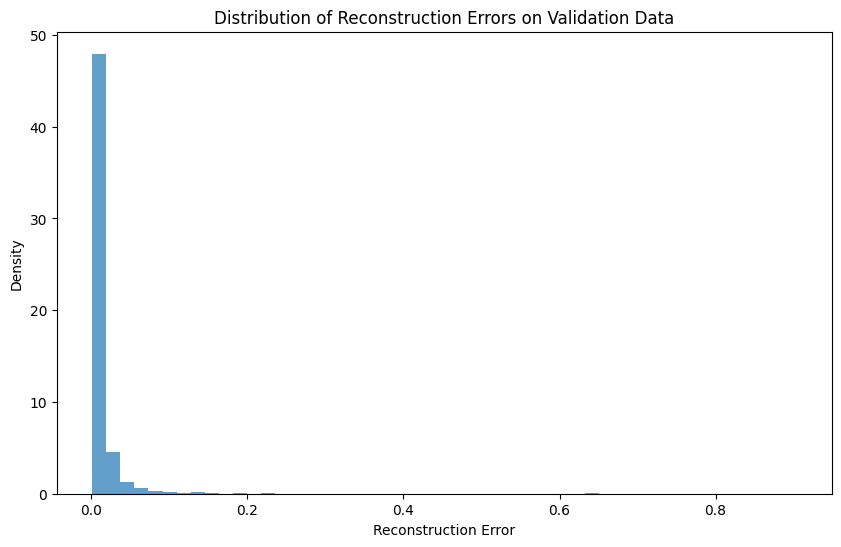

95th Percentile Reconstruction Error (Threshold): 0.0375
99th Percentile Reconstruction Error (Threshold): 0.1110

This threshold can be used to classify new data points: 
If a new data point's reconstruction error is above the threshold, it is considered an anomaly.


In [ ]:
## Determining the Threshold

# Visualize the distribution of reconstruction errors for normal data
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors, bins=50, density=True, alpha=0.7)
plt.title('Distribution of Reconstruction Errors on Validation Data')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.show()

# A common approach for anomaly detection is to set a threshold based on a percentile
# of the reconstruction errors of normal data. For example, the 95th or 99th percentile.

threshold_95_percentile = np.percentile(reconstruction_errors, 95)
threshold_99_percentile = np.percentile(reconstruction_errors, 99)

print(f"95th Percentile Reconstruction Error (Threshold): {threshold_95_percentile:.4f}")
print(f"99th Percentile Reconstruction Error (Threshold): {threshold_99_percentile:.4f}")

print("\nThis threshold can be used to classify new data points: ")
print("If a new data point's reconstruction error is above the threshold, it is considered an anomaly.")

This is a critical section where the trained autoencoder is applied to a new, unseen dataset that contains both normal and anomalous traffic (`mixed_traffic_data`). The goal is to evaluate how well the autoencoder can distinguish anomalies in a real-world scenario.

### Data Loading and Preprocessing:

1.  **Load Data**: The `mixed_traffic_data` is loaded from a CSV file. The `try-except` block handles potential `FileNotFoundError`.
2.  **Feature Dropping**: The same `features_to_drop` that were applied to the training data (`data_1_noAttacks`) are applied here to `mixed_traffic_data_processed`. This ensures consistency in the feature set.
3.  **One-Hot Encoding**: The 'protocol' column is one-hot encoded, just as it was for the training data.
4.  **Feature Alignment**: This is a crucial step. It ensures that the columns of the `mixed_traffic_features` match the columns of `X_train` (the training features). If the mixed traffic data has protocols not seen in training, or vice-versa, `reindex` with `fill_value=0` handles this, preventing errors during prediction.
5.  **Scaling**: The `mixed_traffic_features_aligned` are scaled using the *same* `StandardScaler` (`scaler`) that was fitted on the training data. This is essential to ensure that the scaling is consistent across training and test sets.

### Anomaly Detection and Evaluation:

1.  **Reconstruction**: The `scaled mixed_traffic_data` is passed through the `autoencoder` to get `mixed_traffic_reconstructed_reg`.
2.  **Error Calculation**: `mixed_traffic_reconstruction_errors_reg` are calculated, representing how well the autoencoder reconstructs each data point in the mixed traffic.
3.  **Analysis by Label**: The `reconstruction_error_reg` is added as a new column to the `mixed_traffic_data`. If ground truth `label`s are available, the average reconstruction error for normal (label 0) and attack (labels 1, 2) traffic is printed. This allows for a direct comparison of reconstruction errors for different classes.
4.  **Visualization**: A histogram compares the distribution of reconstruction errors for normal and attack traffic in the mixed dataset. Ideally, attack traffic should show a higher distribution of errors.

The output clearly shows that attack traffic (labels 1 and 2) has significantly higher average reconstruction errors than normal traffic (label 0), indicating the autoencoder's ability to differentiate.

Mixed Traffic data loaded successfully.
Processed Mixed Traffic data shape: (19532, 60)
611/611 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

--- Reconstruction Error for Mixed Traffic (Regularized Autoencoder) ---
Average Reconstruction Error (MSE) on Mixed Traffic data: 0.0233
Max Reconstruction Error on Mixed Traffic data: 2.3165
Min Reconstruction Error on Mixed Traffic data: 0.0010

Reconstruction Error by Label (Regularized Autoencoder):
label
0    0.011465
1    0.060246
2    0.115233
Name: reconstruction_error_reg, dtype: float64


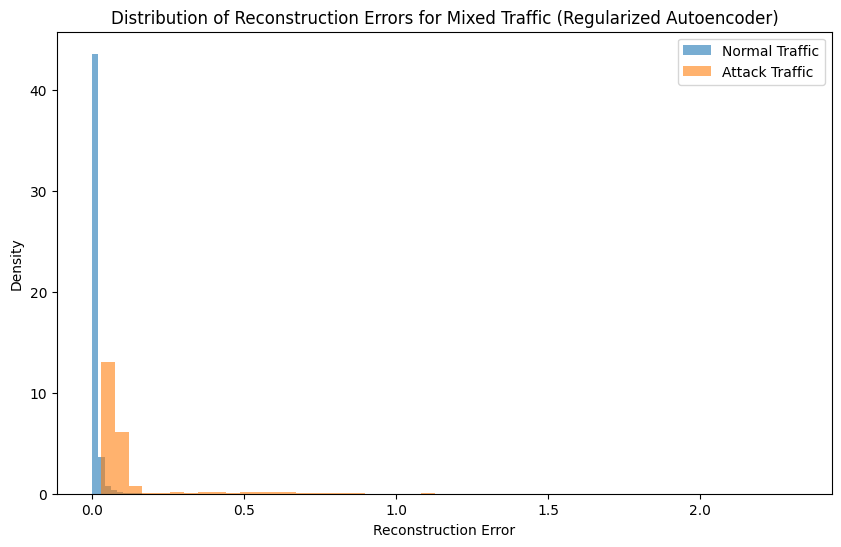


First 10 reconstruction errors for Mixed Traffic (Regularized Autoencoder):
0    0.029270
1    0.029204
2    0.033346
3    0.043331
4    0.007791
5    0.029830
6    0.003859
7    0.043202
8    0.008808
9    0.030212
dtype: float64


In [ ]:
## Testing on Mixed Traffic

# 1. Load the mixed traffic dataset
try:
    mixed_traffic_data = pd.read_csv("/content/drive/MyDrive/Grad project/dataset_v2_master_training.csv", low_memory=False)
    print("Mixed Traffic data loaded successfully.")
except FileNotFoundError:
    print("Error: 'dataset_v2_master_mixedTraffic.csv' not found. Please ensure the file is in the correct path.")
    mixed_traffic_data = None # Set to None to prevent further errors

if mixed_traffic_data is not None:
    # 2. Apply the same feature dropping as the training data
    # Ensure 'label' and 'attack_type' are handled, though 'label' might be used for ground truth later
    mixed_traffic_data_processed = mixed_traffic_data.copy()

    # Drop initial set of features (timestamp, IPs, snort_sid, etc.)
    original_features_to_drop_step_1 = [
        'timestamp',
        'src_ip',
        'dst_ip',
        'src_port',
        'dst_port',
        'top_dst_port',
        'snort_sid',
        'active_snort_alerts',
        'distinct_alert_types',
    ]

    original_features_to_drop_step_2 = [
        "incomplete_ratio",
        "packets_per_second",
        "total_bytes",
        "device_pkt_rate_deviation",
        "is_broadcast_dst",
        "arp_reply_request_ratio",
        "device_byte_rate_deviation",
        "arp_gratuitous_count",
        "inter_arrival_std",
        "is_registered_iot",
        "ip_mac_binding_changes",
        "rst_count",
        "arp_unsolicited_count",
        "well_known_port_ratio",
        "device_pkt_rate_deviation", # Duplicate in original list
        "burst_duration_avg",
        "broadcast_ratio",
        "arp_reply_rate",
        "burst_count",
        "psh_count",
        "device_unique_dst_ips",
    ]

    # Apply both sets of drops to a fresh copy of mixed_traffic_data
    mixed_traffic_data_preprocessed = mixed_traffic_data.copy()
    mixed_traffic_data_preprocessed = mixed_traffic_data_preprocessed.drop(columns=original_features_to_drop_step_1, axis=1, errors='ignore')
    mixed_traffic_data_preprocessed = mixed_traffic_data_preprocessed.drop(columns=original_features_to_drop_step_2, axis=1, errors='ignore')

    # 3. One-hot encode the 'protocol' column
    mixed_traffic_data_encoded = pd.get_dummies(mixed_traffic_data_preprocessed, prefix='protocol')

    # 4. Separate features from 'label' and 'attack_type' (if present)
    # Keep original label and attack_type for analysis later if needed
    if 'label' in mixed_traffic_data_encoded.columns:
        mixed_traffic_labels = mixed_traffic_data_encoded['label']
        mixed_traffic_features = mixed_traffic_data_encoded.drop('label', axis=1)
    else:
        mixed_traffic_labels = None # Or create a dummy series
        mixed_traffic_features = mixed_traffic_data_encoded.copy()

    if 'attack_type' in mixed_traffic_features.columns:
        mixed_traffic_attack_types = mixed_traffic_features['attack_type']
        mixed_traffic_features = mixed_traffic_features.drop('attack_type', axis=1)
    else:
        mixed_traffic_attack_types = None

    # Align columns between training features and mixed traffic features
    # This is crucial if get_dummies creates different columns (e.g., if a protocol is missing)
    # We need to ensure X_train has been defined in an earlier cell. It should be from the 'Splitting the data' section.
    # If X_train is not available, this cell will fail.
    train_cols = X_train.columns # Using X_train to get the original columns after scaling and splitting
    mixed_traffic_features_aligned = mixed_traffic_features.reindex(columns=train_cols, fill_value=0)

    # 5. Scale the features using the *same* StandardScaler fitted on the training data
    # The `scaler` object from the training phase should be available in the kernel.
    mixed_traffic_scaled = scaler.transform(mixed_traffic_features_aligned)
    mixed_traffic_scaled_df = pd.DataFrame(mixed_traffic_scaled, columns=mixed_traffic_features_aligned.columns)

    print(f"Processed Mixed Traffic data shape: {mixed_traffic_scaled_df.shape}")

    # 6. Predict reconstructions for the mixed traffic data using the REGULARIZED autoencoder
    mixed_traffic_reconstructed_reg = autoencoder.predict(mixed_traffic_scaled_df)

    # 7. Calculate reconstruction errors for the REGULARIZED autoencoder
    mixed_traffic_reconstruction_errors_reg = np.mean(np.square(mixed_traffic_scaled_df - mixed_traffic_reconstructed_reg), axis=1)

    print("\n--- Reconstruction Error for Mixed Traffic (Regularized Autoencoder) ---")
    print(f"Average Reconstruction Error (MSE) on Mixed Traffic data: {np.mean(mixed_traffic_reconstruction_errors_reg):.4f}")
    print(f"Max Reconstruction Error on Mixed Traffic data: {np.max(mixed_traffic_reconstruction_errors_reg):.4f}")
    print(f"Min Reconstruction Error on Mixed Traffic data: {np.min(mixed_traffic_reconstruction_errors_reg):.4f}")

    # Add the reconstruction errors back to the original mixed traffic data for easier analysis
    mixed_traffic_data['reconstruction_error_reg'] = mixed_traffic_reconstruction_errors_reg

    if mixed_traffic_labels is not None:
        mixed_traffic_data['label'] = mixed_traffic_labels.values # Re-add the label for comparison
        # Display errors for normal vs. attack (assuming 0=normal, 1=attack in mixed traffic)
        print("\nReconstruction Error by Label (Regularized Autoencoder):")
        print(mixed_traffic_data.groupby('label')['reconstruction_error_reg'].mean())

        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.hist(mixed_traffic_data[mixed_traffic_data['label'] == 0]['reconstruction_error_reg'], bins=50, density=True, alpha=0.6, label='Normal Traffic')
        plt.hist(mixed_traffic_data[mixed_traffic_data['label'] != 0]['reconstruction_error_reg'], bins=50, density=True, alpha=0.6, label='Attack Traffic')
        plt.title('Distribution of Reconstruction Errors for Mixed Traffic (Regularized Autoencoder)')
        plt.xlabel('Reconstruction Error')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

    print("\nFirst 10 reconstruction errors for Mixed Traffic (Regularized Autoencoder):")
    print(mixed_traffic_reconstruction_errors_reg[:10])

This cell evaluates the performance of the autoencoder in detecting anomalies in the `mixed_traffic_data` using the previously determined `anomaly_threshold_reg` (95th percentile from the validation set). It uses standard classification metrics like Precision, Recall, F1-score, and a Confusion Matrix.

### Steps:

1.  **Threshold Application**: The `mixed_traffic_reconstruction_errors_reg` are compared against `anomaly_threshold_reg`. Data points with errors greater than the threshold are classified as `1` (anomaly), otherwise `0` (normal).
2.  **True Labels Preparation**: The original `label` column from `mixed_traffic_data` is converted into a binary format (`y_true_mixed_traffic`), where `0` means normal and any other value (`1`, `2`) means anomaly.
3.  **Classification Report**: A detailed `classification_report` is printed, showing precision, recall, and F1-score for both 'Normal' and 'Anomaly' classes. This gives a comprehensive view of the model's performance.
4.  **Confusion Matrix**: A `confusion_matrix` is calculated and displayed, and also visualized using a heatmap. This matrix breaks down the predictions into:
    *   **True Negatives (TN)**: Correctly predicted normal traffic.
    *   **False Positives (FP)**: Normal traffic incorrectly predicted as anomaly.
    *   **False Negatives (FN)**: Attack traffic incorrectly predicted as normal.
    *   **True Positives (TP)**: Correctly predicted attack traffic.
5.  **Threshold Sweeping**: To understand the impact of different thresholds, the cell iterates through various percentiles (90th, 92nd, 95th, 97th, 99th) and calculates the precision and recall for each. This helps in selecting an optimal threshold based on the desired balance between precision and recall.

The output provides a detailed assessment of the model's anomaly detection capabilities, showing good overall accuracy and a clear trade-off between precision and recall at different thresholds.

Anomaly Threshold (95th percentile - Regularized Model): 0.0375

--- Classification Report on Mixed Traffic Data (95th percentile threshold - Regularized Model) ---
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     17189
     Anomaly       0.76      0.97      0.85      2343

    accuracy                           0.96     19532
   macro avg       0.88      0.96      0.91     19532
weighted avg       0.97      0.96      0.96     19532


--- Confusion Matrix on Mixed Traffic Data (95th percentile threshold - Regularized Model) ---
[[16460   729]
 [   79  2264]]


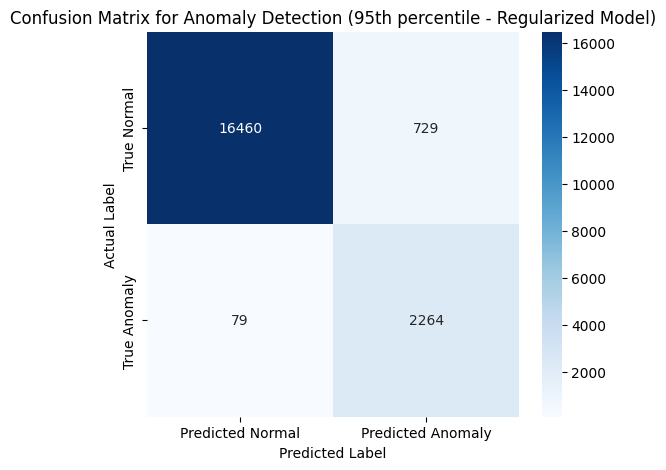


--- Sweeping different percentile thresholds (Regularized Model) ---
P90 (Regularized Model) | threshold=0.0253 | precision=0.604 | recall=1.000
P92 (Regularized Model) | threshold=0.0289 | precision=0.659 | recall=1.000
P95 (Regularized Model) | threshold=0.0375 | precision=0.756 | recall=0.966
P97 (Regularized Model) | threshold=0.0548 | precision=0.779 | recall=0.606
P99 (Regularized Model) | threshold=0.1110 | precision=0.741 | recall=0.161


In [ ]:
## Model Evaluation (Regularized Autoencoder)

from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define anomaly threshold (using the 95th percentile from validation data for regularized model)
anomaly_threshold_reg = threshold_95_percentile

# Classify mixed traffic data based on the threshold
mixed_traffic_predictions_reg = (mixed_traffic_reconstruction_errors_reg > anomaly_threshold_reg).astype(int)

# Prepare true labels for evaluation (re-use y_true_mixed_traffic)
# Assuming '0' is normal and anything else (1, 2) is an anomaly
y_true_mixed_traffic = mixed_traffic_data['label'].apply(lambda x: 1 if x != 0 else 0)

print(f"Anomaly Threshold (95th percentile - Regularized Model): {anomaly_threshold_reg:.4f}")

print("\n--- Classification Report on Mixed Traffic Data (95th percentile threshold - Regularized Model) ---")
print(classification_report(y_true_mixed_traffic, mixed_traffic_predictions_reg, target_names=['Normal', 'Anomaly']))

print("\n--- Confusion Matrix on Mixed Traffic Data (95th percentile threshold - Regularized Model) ---")
conf_matrix_reg = confusion_matrix(y_true_mixed_traffic, mixed_traffic_predictions_reg)
print(conf_matrix_reg)

# Optional: Visualize the confusion matrix for better understanding
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['True Normal', 'True Anomaly'])
plt.title('Confusion Matrix for Anomaly Detection (95th percentile - Regularized Model)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n--- Sweeping different percentile thresholds (Regularized Model) ---")
for pct in [90, 92, 95, 97, 99]:
    # Use the reconstruction errors from the *regularized* model's validation data
    threshold = np.percentile(reconstruction_errors, pct)
    preds = (mixed_traffic_reconstruction_errors_reg > threshold).astype(int)
    recall = recall_score(y_true_mixed_traffic, preds)
    precision = precision_score(y_true_mixed_traffic, preds)
    print(f"P{pct} (Regularized Model) | threshold={threshold:.4f} | precision={precision:.3f} | recall={recall:.3f}")

This cell implements Stratified K-Fold Cross-Validation to provide a more robust evaluation of the autoencoder's anomaly detection performance on the mixed traffic data. Instead of a single train-test split, the data is divided into `n_splits` (20 in this case) folds, and the evaluation is repeated `n_splits` times. In each iteration, a different fold is used as the test set, and the remaining folds as the training set (though here the autoencoder is already trained, so it's evaluating performance on different test splits).

### Steps:

1.  **Stratified K-Fold**: `StratifiedKFold` is used to ensure that the proportion of normal and anomalous samples is roughly the same in each fold, which is crucial for imbalanced datasets.
2.  **Iteration over Folds**: For each fold:
    *   A test set (`X_test_fold`, `y_test_fold`) is extracted.
    *   The `autoencoder` predicts reconstructions for `X_test_fold`.
    *   Reconstruction errors are calculated (`reconstruction_errors_fold`).
    *   Predictions (`predictions_fold`) are made by applying the `anomaly_threshold_reg`.
    *   Precision, Recall, F1-score, and Confusion Matrix are calculated and printed for the current fold.
3.  **Average Metrics**: After all folds are processed, the average precision, recall, and F1-score across all folds are calculated, along with their standard deviations. This gives a more reliable estimate of the model's performance and its variability.

The results from cross-validation show that the model consistently achieves good recall (high true positive rate), meaning it effectively identifies most anomalies. Precision varies, indicating some false positives are present, which is common in anomaly detection. The F1-score provides a balanced measure, and the standard deviations indicate the stability of these metrics across different data splits.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

# Assuming mixed_traffic_scaled_df and y_true_mixed_traffic are available from previous cells
# Assuming autoencoder and anomaly_threshold_reg are also available

n_splits = 20 # Number of folds for cross-validation (changed from 5 to 10)
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
precision_scores = []
recall_scores = []
f1_scores = []

print(f"Performing {n_splits}-fold cross-validation on mixed traffic data...")

for fold, (train_idx, test_idx) in enumerate(skf.split(mixed_traffic_scaled_df, y_true_mixed_traffic)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    X_test_fold = mixed_traffic_scaled_df.iloc[test_idx]
    y_test_fold = y_true_mixed_traffic.iloc[test_idx]

    # Predict reconstructions for the current test fold using the already trained autoencoder
    X_test_reconstructed_fold = autoencoder.predict(X_test_fold, verbose=0)

    # Calculate reconstruction errors for the test fold
    reconstruction_errors_fold = np.mean(np.square(X_test_fold - X_test_reconstructed_fold), axis=1)

    # Apply the pre-determined anomaly threshold to get predictions
    predictions_fold = (reconstruction_errors_fold > anomaly_threshold_reg).astype(int)

    # Calculate and store metrics
    precision = precision_score(y_test_fold, predictions_fold)
    recall = recall_score(y_test_fold, predictions_fold)
    f1 = f1_score(y_test_fold, predictions_fold)
    conf_matrix = confusion_matrix(y_test_fold, predictions_fold)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

# Print average metrics across all folds
print("\n--- Average Metrics Across All Folds ---")
print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")


Performing 20-fold cross-validation on mixed traffic data...

--- Fold 1/20 ---
Precision: 0.7244
Recall: 0.9658
F1-Score: 0.8278
Confusion Matrix:
[[817  43]
 [  4 113]]

--- Fold 2/20 ---
Precision: 0.7261
Recall: 0.9744
F1-Score: 0.8321
Confusion Matrix:
[[817  43]
 [  3 114]]

--- Fold 3/20 ---
Precision: 0.7500
Recall: 0.9487
F1-Score: 0.8377
Confusion Matrix:
[[823  37]
 [  6 111]]

--- Fold 4/20 ---
Precision: 0.7081
Recall: 0.9744
F1-Score: 0.8201
Confusion Matrix:
[[813  47]
 [  3 114]]

--- Fold 5/20 ---
Precision: 0.7434
Recall: 0.9658
F1-Score: 0.8401
Confusion Matrix:
[[821  39]
 [  4 113]]

--- Fold 6/20 ---
Precision: 0.8182
Recall: 1.0000
F1-Score: 0.9000
Confusion Matrix:
[[834  26]
 [  0 117]]

--- Fold 7/20 ---
Precision: 0.7550
Recall: 0.9744
F1-Score: 0.8507
Confusion Matrix:
[[823  37]
 [  3 114]]

--- Fold 8/20 ---
Precision: 0.7639
Recall: 0.9402
F1-Score: 0.8429
Confusion Matrix:
[[826  34]
 [  7 110]]

--- Fold 9/20 ---
Precision: 0.7197
Recall: 0.9658
F1-Scor

This final cell saves the trained autoencoder model to Google Drive. This is a crucial step for deployment, as it allows you to reuse the trained model without having to retrain it every time.

### Steps:

1.  **Define Save Path**: The `model_save_path` variable specifies where the model will be saved, including the filename `anomaly_detection_autoencoder_model.keras`.
2.  **Create Directory**: `os.makedirs` ensures that the specified directory in Google Drive exists. `exist_ok=True` prevents an error if the directory already exists.
3.  **Save Model**: The `autoencoder.save(model_save_path)` command serializes the entire model (architecture, weights, and optimizer state) into a single file in the Keras native format.

Saving the model makes it portable and ready for future use, such as loading it for inference on new, live data.

In [ ]:
import os

# Define the path to save the model in Google Drive
model_save_path = '/content/drive/MyDrive/anomaly_detection_autoencoder_model.keras'

# Create the directory if it doesn't exist (optional, but good practice)
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the autoencoder model
autoencoder.save(model_save_path)

print(f"Autoencoder model saved successfully to: {model_save_path}")

Autoencoder model saved successfully to: /content/drive/MyDrive/anomaly_detection_autoencoder_model.keras
